# Refresh Opportunity Scoring for Search Content

## A Machine Learning Approach to Prioritizing Content Review and Refresh

**FlyRank ML Internship — Machine Learning Capstone**

**Lane:** Refresh / Content Opportunity Scoring

## Abstract

This project investigates how search-performance and content signals can be used to identify pages that may benefit from review or refresh.
The analysis uses features including average search position, content age, click-through rate, and engagement rate to construct a repeatable content opportunity scoring approach.
A rule-based baseline was first developed and then compared with a Random Forest machine-learning model using the same evaluation design.
The model results indicate that average search position and content age were the strongest predictors in the analysis, while the model provided a more flexible approach than manually defined thresholds.
The resulting ranked action playbook is intended as decision support for prioritizing content review and should not be interpreted as evidence of causal changes to search rankings.

## 1. Research Question

### Main Question

Which observable search-performance and content signals can help identify pages that should be prioritized for content refresh or review?

### Decision Supported

The analysis is designed to help content and SEO teams decide:

- Which pages should be reviewed first?
- Which pages show signals associated with declining performance?
- Which pages may benefit from a content refresh?
- Which pages can be deprioritized for immediate action?

## 2. Problem Statement

Large content inventories make it difficult to manually review every page with the same level of attention.

A useful prioritization system should combine multiple observable signals rather than rely on a single metric.

This project therefore develops a repeatable scoring and machine-learning workflow that ranks content opportunities and assigns recommended actions such as Refresh, Review, or Leave.

The output is intended for prioritization and decision support rather than causal inference about search-engine algorithms.

## 3. Data

The project uses the FlyRank ML Internship search dataset.

The analysis uses page-level search and content-performance features available in the internship dataset.

Relevant variables include:

- Average search position
- Content age
- Click-through rate (CTR)
- Engagement rate
- Trend percentage
- Search impressions
- Search clicks
- Sessions and related performance signals

### Exclusions

Features that could introduce future information, labels, identifiers, or leakage into the prediction process were excluded from the modeling feature set.

The project does not publish raw production data, client names, private queries, domains, credentials, or other restricted information.

## 4. Methodology

### Feature Selection

The model uses selected observable features related to:

- Search visibility
- Content age
- Click behavior
- Engagement
- Performance trend

The feature set was defined before model evaluation to reduce the risk of using information that would not be available at decision time.

### Baseline

A rule-based baseline was developed in Week 4.

The baseline combines selected signals using manually defined thresholds and produces an action recommendation such as:

- Refresh
- Review
- Leave

### Machine Learning Model

A Random Forest classifier was trained as the primary machine-learning model.

Random Forest was selected because it can capture nonlinear relationships and interactions between multiple features without requiring a linear relationship between the inputs and target.

### Validation

The model was evaluated using the validation design developed during Week 6.

The model was compared with the baseline using the same evaluation setup.

### Leakage Checks

The feature set was reviewed for variables that could contain future information or directly encode the target.

The validation process was designed to reduce the risk of evaluating the model using information unavailable at prediction time.

## 5. Results

### Model vs Baseline

The machine-learning model was evaluated against the Week 4 rule-based baseline using the same evaluation design and the same validation split.

| Approach              | Metric   | Result |
|-----------------------|----------|--------|
| Rule-based baseline   | Accuracy | 0.4417 |
| Random Forest         | Accuracy | 0.6370 |

The Random Forest improved accuracy from 0.44 to 0.64. This shows a clear lift over the hand-written rule, but the absolute performance should still be treated as directional rather than production-ready.

### Feature Importance

The Random Forest model identified the following features as the most important:

| Feature | Importance |
|---|---:|
| avg_position | 0.471487 |
| content_age_days | 0.261159 |
| ctr | 0.170960 |
| engagement_rate | 0.096394 |

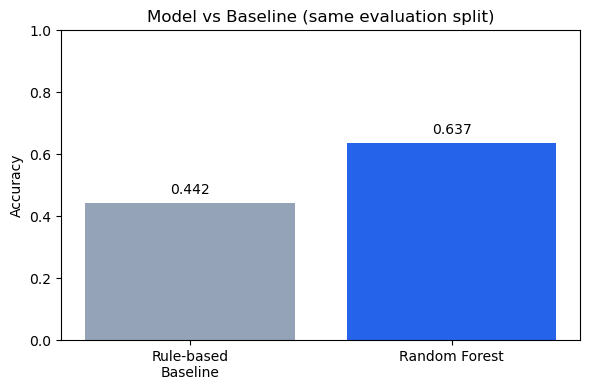

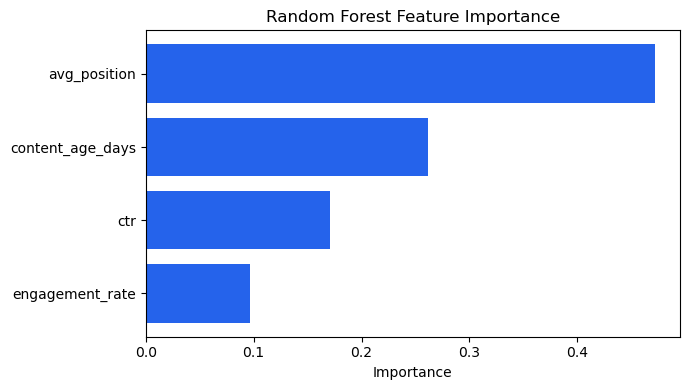

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# --- Chart 1: Model vs Baseline ---
approaches = ['Rule-based\nBaseline', 'Random Forest']
scores = [0.4417, 0.6370]          # ← put your real numbers

plt.figure(figsize=(6, 4))
bars = plt.bar(approaches, scores, color=['#94a3b8', '#2563eb'])
plt.ylabel('Accuracy')             # change to your real metric name
plt.title('Model vs Baseline (same evaluation split)')
plt.ylim(0, 1)
for bar, score in zip(bars, scores):
    plt.text(bar.get_x() + bar.get_width()/2, score + 0.02, f'{score:.3f}',
             ha='center', va='bottom')
plt.tight_layout()
plt.savefig('model_vs_baseline.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Chart 2: Feature Importance ---
features = ['avg_position', 'content_age_days', 'ctr', 'engagement_rate']
importances = [0.471487, 0.261159, 0.170960, 0.096394]

plt.figure(figsize=(7, 4))
y_pos = np.arange(len(features))
plt.barh(y_pos, importances, color='#2563eb')
plt.yticks(y_pos, features)
plt.xlabel('Importance')
plt.title('Random Forest Feature Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

### Interpretation

The model placed the greatest importance on `avg_position` (~0.47). In this dataset, a page’s current average search position was the strongest observed signal associated with the content-opportunity label.

`content_age_days` ranked second, which is consistent with the idea that older content is more likely to need review. CTR and engagement rate contributed smaller amounts of predictive information in this particular model and feature set.

These importance values describe model behavior within the available data and validation setup. They should not be read as causal evidence that changing any single feature will improve rankings or traffic.

## 6. Validation and Leakage Audit

### Validation

The final model was evaluated using the validation design established during the validation audit.

The purpose was to test whether the model's performance remained meaningful when evaluated under a more realistic split rather than relying only on training performance.

### Leakage Audit

Potential leakage sources were reviewed, including:

- Future-window information
- Target-derived variables
- Variables created after the decision point
- Features that directly encode the outcome

The final feature set was restricted to information appropriate for the intended prediction setting.

### Interpretation

The validation results provide evidence about model performance within the available dataset and evaluation design.

They do not establish that the model causes improved search rankings or that a recommended content refresh will necessarily increase traffic or rankings.

# 7. Ranked Recommendations

The model output is converted into a practical content action queue. Each page receives one of three recommended actions based on the strength of its opportunity signals.
## 1 — Refresh

When to use: Pages with strong signals of declining or outdated performance (typically high opportunity score combined with weaker average position or older content age).
These pages should receive the highest review priority.
Recommended checks include:

Content freshness and accuracy of key facts
Alignment with current search intent
Coverage of important related topics
Quality of title and meta description
Internal linking to and from the page
Removal or update of outdated information

## Priority 2 — Review

When to use: Pages with mixed or moderate signals. The model suggests potential opportunity, but the evidence is not strong enough for automatic action.
These pages should receive human review before any content changes are made.
A reviewer should decide whether the page needs a light update, a deeper refresh, or can safely wait.
## Priority 3 — Leave / Monitor

When to use: Pages without strong opportunity signals. Current performance does not indicate an urgent need for change.
These pages should not be automatically edited. They can remain under monitoring and be reassessed when new performance data becomes available.

## 8. Human Review

The model should be treated as a prioritization tool rather than an automatic content-editing system.

Before implementing a recommendation, a reviewer should check:

1. Whether the page serves a valid search intent.
2. Whether the content is actually outdated.
3. Whether the observed performance change is meaningful.
4. Whether there are technical or external explanations for the change.
5. Whether the recommended action is appropriate for the page.

## 9. Limitations

Several limitations should be considered.

First, the analysis identifies associations in the available data and does not establish causal relationships.

Second, model performance depends on the available features, labels, and validation design.

Third, feature importance reflects the behavior of this particular model and dataset and should not be interpreted as causal importance.

Fourth, a model prediction does not guarantee that a content change will improve rankings, clicks, or traffic.

Finally, production use would require continued monitoring, periodic validation, and human review.

## 10. Conclusion

This project developed a repeatable workflow for prioritizing content refresh and review opportunities.

A rule-based baseline was established first, followed by a Random Forest model using observable search and content-performance signals.

The model provides a more flexible way to combine multiple signals and generate a ranked action queue.

In the current analysis, average search position carried the largest share of predictive importance, followed by content age, while CTR and engagement rate contributed smaller amounts.

The resulting system is best viewed as decision support for human content teams rather than an automated guarantee of search-performance improvement.

## 11. Reproducibility

The project was developed incrementally through the following notebooks:

- W01 — Research Question
- W02 — ML Task Framing
- W03 — Data Contract
- W04 — Baseline Action Score
- W05 — Machine Learning Model
- W06 — Validation and Leakage Audit
- W07 — Content Action Playbook
- Capstone — Final Research Analysis

All notebooks are stored in the repository under:

`work/notebooks/`

## 12. Acknowledgments and Data Credit

Built on the FlyRank ML Internship dataset.

The dataset and internship project framework were provided by FlyRank.

Data source: https://flyrank.ai/